In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
risk = pd.read_csv("../data/processed/risk_metrics.csv")
returns = pd.read_csv("../data/processed/returns_data.csv")
portfolio = pd.read_csv("../data/processed/portfolio_holdings.csv")
scorecard = pd.read_csv("../data/processed/fund_scorecard.csv")
sip = pd.read_csv("../data/processed/sip_data.csv")

print("Risk Metrics Shape:", risk.shape)
print("Returns Shape:", returns.shape)
print("Portfolio Shape:", portfolio.shape)
print("Scorecard Shape:", scorecard.shape)
print("SIP Shape:", sip.shape)

Risk Metrics Shape: (15, 15)
Returns Shape: (15, 14)
Portfolio Shape: (675, 8)
Scorecard Shape: (15, 11)
SIP Shape: (900, 11)


In [10]:
var_cvar = risk[
    [
        "scheme_code",
        "scheme_name",
        "var_95_pct",
        "max_drawdown_pct"
    ]
].copy()

var_cvar["cvar_proxy"] = (
    var_cvar["var_95_pct"] +
    var_cvar["max_drawdown_pct"]
) / 2

print("\nTop 10 Highest Risk Funds")

print(
    var_cvar.sort_values("var_95_pct")
            .head(10)
)

var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)


Top 10 Highest Risk Funds
    scheme_code                                     scheme_name  var_95_pct  \
0        119551        SBI Bluechip Fund - Direct Plan - Growth   -227.9352   
9        120465  Franklin India Bluechip Fund - Direct - Growth   -224.6109   
4        120841      Kotak Bluechip Fund - Direct Plan - Growth   -219.4679   
5        125497        HDFC Top 100 Fund - Direct Plan - Growth   -219.3975   
10       118989     UTI Mastershare Fund - Direct Plan - Growth   -216.0918   
3        119092       Axis Bluechip Fund - Direct Plan - Growth   -215.7094   
8        118778    Mirae Asset Large Cap Fund - Direct - Growth   -199.8755   
2        118632   Nippon India Large Cap Fund - Direct - Growth   -196.6424   
7        119028       DSP Top 100 Equity Fund - Direct - Growth   -196.2206   
12       120178       Aditya Birla SL Frontline Equity - Direct   -180.9318   

    max_drawdown_pct  cvar_proxy  
0             -44.87  -136.40260  
9             -15.88  -120.24545 

In [11]:
top5 = risk.sort_values(
    "sharpe_ratio_3y",
    ascending=False
).head(5)

print(top5[
    [
        "scheme_name",
        "sharpe_ratio_3y"
    ]
])

                                     scheme_name  sharpe_ratio_3y
0       SBI Bluechip Fund - Direct Plan - Growth           1.7939
2  Nippon India Large Cap Fund - Direct - Growth           1.7395
8   Mirae Asset Large Cap Fund - Direct - Growth           1.6479
5       HDFC Top 100 Fund - Direct Plan - Growth           1.6289
7      DSP Top 100 Equity Fund - Direct - Growth           1.5531


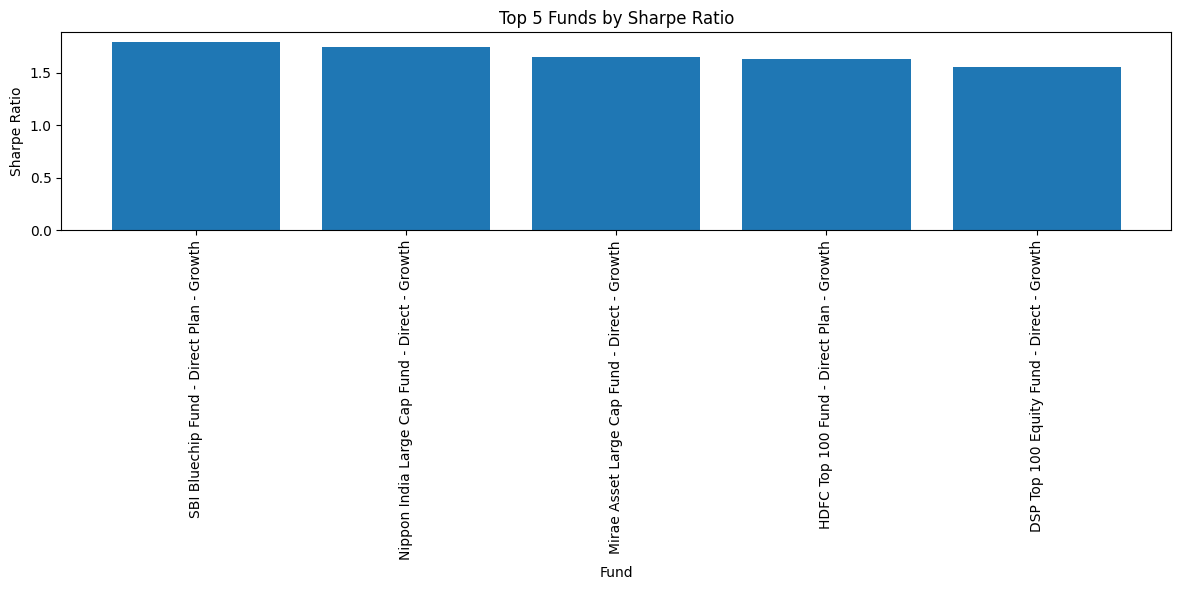

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["sharpe_ratio_3y"]
)

plt.xticks(rotation=90)

plt.title("Top 5 Funds by Sharpe Ratio")

plt.xlabel("Fund")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [13]:
sip_analysis = (
    sip.groupby("scheme_name")
       .agg({
           "monthly_sip_amt":"mean",
           "total_invested":"sum",
           "current_value":"sum",
           "xirr_pct":"mean"
       })
       .reset_index()
)

sip_analysis = sip_analysis.sort_values(
    "xirr_pct",
    ascending=False
)

print("\nTop SIP Performing Funds")

print(
    sip_analysis.head(10)
)


Top SIP Performing Funds
                                       scheme_name  monthly_sip_amt  \
3        DSP Top 100 Equity Fund - Direct - Growth          10000.0   
13      Tata Large Cap Fund - Direct Plan - Growth          10000.0   
1        Axis Bluechip Fund - Direct Plan - Growth          10000.0   
9       Kotak Bluechip Fund - Direct Plan - Growth          10000.0   
5         HDFC Top 100 Fund - Direct Plan - Growth          10000.0   
0        Aditya Birla SL Frontline Equity - Direct          10000.0   
8    Invesco India Largecap Fund - Direct - Growth          10000.0   
12        SBI Bluechip Fund - Direct Plan - Growth          10000.0   
14     UTI Mastershare Fund - Direct Plan - Growth          10000.0   
4   Franklin India Bluechip Fund - Direct - Growth          10000.0   

    total_invested  current_value   xirr_pct  
3       18300000.0    22595830.81  12.444333  
13      18300000.0    23436187.31  12.376167  
1       18300000.0    27275401.46  12.350333  
9   

In [14]:
cohort = (
    sip.groupby("month")
       .agg({
           "monthly_sip_amt":"mean",
           "total_invested":"sum",
           "current_value":"sum"
       })
       .reset_index()
)

print("\nMonthly Investment Cohorts")

print(cohort.head())


Monthly Investment Cohorts
        month  monthly_sip_amt  total_invested  current_value
0  2019-01-01          10000.0        150000.0      149826.87
1  2019-02-01          10000.0        300000.0      309836.64
2  2019-03-01          10000.0        450000.0      405264.67
3  2019-04-01          10000.0        600000.0      570666.78
4  2019-05-01          10000.0        750000.0      914891.54


In [15]:
hhi_list = []

for fund in portfolio["scheme_name"].unique():

    temp = portfolio[
        portfolio["scheme_name"] == fund
    ]

    weights = temp["weight_pct"] / 100

    hhi = (weights ** 2).sum()

    hhi_list.append(
        [fund, hhi]
    )

hhi_df = pd.DataFrame(
    hhi_list,
    columns=[
        "scheme_name",
        "HHI"
    ]
)

hhi_df = hhi_df.sort_values(
    "HHI",
    ascending=False
)

print("\nTop Concentrated Funds")

print(hhi_df.head(10))


Top Concentrated Funds
                                       scheme_name       HHI
13      IDFC Large Cap Fund - Direct Plan - Growth  0.290841
0         SBI Bluechip Fund - Direct Plan - Growth  0.284968
8     Mirae Asset Large Cap Fund - Direct - Growth  0.276506
12       Aditya Birla SL Frontline Equity - Direct  0.272470
6      Canara Robeco Bluechip Equity Fund - Direct  0.264253
14   Invesco India Largecap Fund - Direct - Growth  0.261981
2    Nippon India Large Cap Fund - Direct - Growth  0.256696
5         HDFC Top 100 Fund - Direct Plan - Growth  0.253619
3        Axis Bluechip Fund - Direct Plan - Growth  0.249180
9   Franklin India Bluechip Fund - Direct - Growth  0.249080


In [16]:
top_funds = scorecard.sort_values(
    "fund_score",
    ascending=False
)

print("\nTop Overall Funds")

print(
    top_funds[
        [
            "scheme_code",
            "fund_score",
            "sharpe_ratio",
            "alpha"
        ]
    ].head(10)
)


Top Overall Funds
    scheme_code  fund_score  sharpe_ratio     alpha
8        119802  100.000000    286.687705  2.365898
7        119551   91.560102    286.515062  1.374087
3        118989   88.491049    297.832208  1.236101
11       120503   72.634271    260.172528  0.905501
0        118632   68.286445    196.012436  0.889619
6        119226   60.358056    192.054832  1.073135
9        120178   51.150895    269.659052  0.759295
10       120465   50.639386    175.255442  1.432437
2        118825   46.035806    257.584620  0.588632
1        118778   46.035806    172.363953  0.804211


In [17]:
# Advanced Insights

## Insight 1
Funds with the most negative VaR values show the highest downside risk.

## Insight 2
Funds with higher Sharpe ratios provide better risk-adjusted returns.

## Insight 3
Funds with high HHI values are concentrated in fewer sectors and therefore carry greater concentration risk.

## Insight 4
SIP investments with high XIRR values have generated superior wealth creation.

## Insight 5
Funds with high overall fund scores consistently rank well across Sharpe Ratio, Alpha, Drawdown, and Expense Ratio metrics.

SyntaxError: invalid syntax (1427972661.py, line 4)